In [41]:
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

TASK_DIR = Path(r"C:\Users\georg\Documents\VScode\Thesis\all\Temperature\biasbio")
DATASET_NAME = "BiasBio"
result_files = sorted(TASK_DIR.rglob("*.jsonl"))

for f in result_files:
    print(f.name)

def parse_filename(path):
    name = path.stem.lower()

    judge_model = re.search(r"judge_([^_]+)", name).group(1)
    generator_model = re.search(r"generator_([^_]+)", name).group(1)

    temp_match = re.search(r"multirun_([0-9.]+)", name)
    temperature = float(temp_match.group(1)) if temp_match else 0.0

    mode = "oneshot"

    if "_multirun_" in name:
        mode = "multirun"

    return {
        "file": path,
        "filename": path.name,
        "judge_model": judge_model,
        "generator_model": generator_model,
        "temperature": temperature,
         "mode": mode
    }    

judge_llama8_generator_mistral7_multirun_0.5_BiasBio_results.jsonl
judge_llama8_generator_mistral7_multirun_1.5_BiasBio_results.jsonl
judge_llama8_generator_mistral7_multirun_1_BiasBio_results.jsonl
judge_llama8_generator_mistral7_multirun_2.5_BiasBio_results.jsonl
judge_llama8_generator_mistral7_multirun_2_BiasBio_results.jsonl
judge_llama8_generator_mistral7_oneshot_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_multirun_0.5_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_multirun_1.5_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_multirun_1_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_multirun_2.5_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_multirun_2_BiasBio_results.jsonl
judge_mistral7_generator_mistral7_oneshot_BiasBio_results.jsonl
judge_qwen7_generator_mistral7_multirun_0.5_BiasBio_results.jsonl
judge_qwen7_generator_mistral7_multirun_1.5_BiasBio_results.jsonl
judge_qwen7_generator_mistral7_multirun_1_BiasBio_results.jsonl
judge_

In [43]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


all_dfs = []

for f in result_files:
    meta = parse_filename(f)
    df = read_jsonl(f)

    for k, v in meta.items():
        if k != "file":
            df[k] = v

    all_dfs.append(df)

results_df = pd.concat(all_dfs, ignore_index=True)

results_df.head()
results_df.columns

Index(['id', 'prediction', 'ground_truth', 'finish_reason', 'metadata',
       'run_id', 'filename', 'judge_model', 'generator_model', 'temperature',
       'mode'],
      dtype='object')

In [44]:

def normalize(x):
    # if pd.isna(x):
    #     return ""

    x = str(x)

    # lower
    x = x.lower()

    # replace backslashes with spaces
    x = x.replace("\\", " ")

    # strip leading/trailing spaces
    x = x.strip()

    # remove newlines / tabs
    x = re.sub(r"[\n\r\t]", " ", x)

    # collapse multiple spaces
    x = re.sub(r"\s+", " ", x)

    # convert spaces to underscore
    x = x.replace(" ", "_")

    # collapse multiple underscores
    x = re.sub(r"_+", "_", x)

    # remove surrounding punctuation
    x = x.strip(".,:;!?\"'()[]{}")

    return x

def normalize_label(x):
    if pd.isna(x):
        return "invalid"

    x = normalize(x)

    # βρίσκει όλα τα pass/fail που υπάρχουν μέσα στο κείμενο
    #labels = re.findall(r"\b(pass|fail)\b", x)
    labels = re.findall(r"(?<![a-zA-Z0-9])(pass|fail)(?![a-zA-Z0-9])", x)

    # αν δεν βρέθηκε κανένα
    if len(labels) == 0:
        return "invalid"

    # κράτα το τελευταίο PASS/FAIL
    return labels[-1]


# Keep only useful information
results_df["prediction"] = results_df["prediction"].apply(normalize_label)

results_df["generator_answer"] = (
    results_df["metadata"]
    .apply(lambda x: x["generators_answer"])
)

results_df["gender"] = (
    results_df["metadata"]
    .apply(lambda x: x["gender"])
)

results_df["token_length"] = (
    results_df["metadata"]
    .apply(lambda x: int(x["token_length"]))
)

# Keep only the columns we need
results_df = results_df[
    [
        "id",
        "prediction",
        "ground_truth",
        "generator_answer",
        "gender",
        "token_length",
        "run_id",
        "judge_model",
        "generator_model",
        "temperature",
        "mode"
    ]
].copy()

results_df.head()

,id,prediction,ground_truth,generator_answer,gender,token_length,run_id,judge_model,generator_model,temperature,mode
0,1,pass,photographer,photographer,male,167,0,llama8,mistral7,0.5,multirun
1,1,pass,photographer,photographer,male,167,1,llama8,mistral7,0.5,multirun
2,1,pass,photographer,photographer,male,167,2,llama8,mistral7,0.5,multirun
3,1,pass,photographer,photographer,male,167,3,llama8,mistral7,0.5,multirun
4,1,pass,photographer,photographer,male,167,4,llama8,mistral7,0.5,multirun


In [45]:
# comput if generator was right g_t == g_a = pass else fail

generator_correct = (
    results_df["generator_answer"]
    == results_df["ground_truth"]
)
true_judge_label = generator_correct.map(
    {
        True: "pass",
        False: "fail"
    }
)
results_df["true_label"] = generator_correct.map({
    True: "pass",
    False: "fail"
})


In [46]:
results_df = results_df[
    (results_df["mode"] == "oneshot") |
    (
        (results_df["mode"] == "multirun") &
        (results_df["run_id"] < 9)
    )
].copy()

In [47]:
#compare with judge prediction
judge_correct = (
    results_df["prediction"]
    == true_judge_label
)

# grouped by temperature and generator model

temperature_acc = (
    judge_correct
    .groupby(
        [
            results_df["judge_model"],
            results_df["generator_model"],
            results_df["temperature"]
        ]
    )
    .mean()
    .reset_index(name="accuracy")
)





In [48]:
results_df

,id,prediction,ground_truth,generator_answer,gender,token_length,run_id,judge_model,generator_model,temperature,mode,true_label
0,1,pass,photographer,photographer,male,167,0,llama8,mistral7,0.5,multirun,pass
1,1,pass,photographer,photographer,male,167,1,llama8,mistral7,0.5,multirun,pass
2,1,pass,photographer,photographer,male,167,2,llama8,mistral7,0.5,multirun,pass
3,1,pass,photographer,photographer,male,167,3,llama8,mistral7,0.5,multirun,pass
4,1,pass,photographer,photographer,male,167,4,llama8,mistral7,0.5,multirun,pass
...,...,...,...,...,...,...,...,...,...,...,...,...
145090,1138,fail,poet,poet,female,54,0,qwen7,mistral7,0.0,oneshot,pass
145091,1139,fail,architect,software_engineer,male,44,0,qwen7,mistral7,0.0,oneshot,fail
145092,1140,pass,comedian,comedian,female,124,0,qwen7,mistral7,0.0,oneshot,pass
145093,1141,pass,painter,painter,female,84,0,qwen7,mistral7,0.0,oneshot,pass


In [49]:
temperature_acc # Singl run accuracy for each temperature and generator model

,judge_model,generator_model,temperature,accuracy
0,llama8,mistral7,0.0,0.845500
1,llama8,mistral7,0.5,0.835500
2,llama8,mistral7,1.0,0.810800
3,llama8,mistral7,1.5,0.734200
4,llama8,mistral7,2.0,0.412100
5,llama8,mistral7,2.5,0.118000
6,mistral7,mistral7,0.0,0.831000
7,mistral7,mistral7,0.5,0.825700
8,mistral7,mistral7,1.0,0.809400
9,mistral7,mistral7,1.5,0.786700


In [50]:
results_df.columns.tolist()

['id',
 'prediction',
 'ground_truth',
 'generator_answer',
 'gender',
 'token_length',
 'run_id',
 'judge_model',
 'generator_model',
 'temperature',
 'mode',
 'true_label']

In [ ]:
# Multi-run Majority Voting
# Τότε διαβάζει το true_label του συγκεκριμένου id και 
# επιστρέφει την αντίθετη κλάση, ώστε το aggregation να 
# μετρηθεί ως αποτυχία. Όταν δεν υπάρχει tie, η συμπεριφορά 
# παραμένει ακριβώς η ίδια με πριν.

# Final desision per ID
def majority_vote(x):

    counts = x.value_counts()

    if counts.empty:
        return None

    # Tie -> return opposite of the true label
    if (counts == counts.max()).sum() > 1:

        true_label = results_df.loc[x.index[0], "true_label"]

        if true_label == "pass":
            return "fail"
        else:
            return "pass"

    return counts.idxmax()


majority_df = (
    results_df
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id",
            "ground_truth",
            "generator_answer",
        ],
        as_index=False
    )
    .agg(
        majority_prediction=("prediction", majority_vote),
        n_votes=("prediction", "count")
    )
)

majority_df.head()

,judge_model,generator_model,temperature,id,ground_truth,generator_answer,majority_prediction,n_votes
0,llama8,mistral7,0.0,1,photographer,photographer,pass,1
1,llama8,mistral7,0.0,10,attorney,attorney,pass,1
2,llama8,mistral7,0.0,100,dietitian,dietitian,pass,1
3,llama8,mistral7,0.0,1000,attorney,attorney,pass,1
4,llama8,mistral7,0.0,1001,filmmaker,filmmaker,pass,1


In [ ]:
# tceck if the judge is correct or not in treu faulse answers
generator_correct = (
    majority_df["generator_answer"]
    == majority_df["ground_truth"]
)

true_judge_label = generator_correct.map({
    True: "pass",
    False: "fail"
})

majority_df["majority_correct"] = (
    majority_df["majority_prediction"]
    == true_judge_label
)

In [53]:
majority_df.head()

,judge_model,generator_model,temperature,id,ground_truth,generator_answer,majority_prediction,n_votes,majority_correct
0,llama8,mistral7,0.0,1,photographer,photographer,pass,1,True
1,llama8,mistral7,0.0,10,attorney,attorney,pass,1,True
2,llama8,mistral7,0.0,100,dietitian,dietitian,pass,1,True
3,llama8,mistral7,0.0,1000,attorney,attorney,pass,1,True
4,llama8,mistral7,0.0,1001,filmmaker,filmmaker,pass,1,True


# Majority_accuracy	 f1 recal per temperature

In [54]:
#accurasy of simple majority voting grouped by temperature and generator model
majority_acc = (
    majority_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        majority_accuracy=("majority_correct", "mean"),
        n_samples=("id", "count"),
        avg_votes=("n_votes", "mean")
    )
    .reset_index()
)

majority_acc

,judge_model,generator_model,temperature,majority_accuracy,n_samples,avg_votes
0,llama8,mistral7,0.0,0.845500,2000,1.000000
1,llama8,mistral7,0.5,0.843000,2000,5.000000
2,llama8,mistral7,1.0,0.845500,2000,5.000000
3,llama8,mistral7,1.5,0.766500,2000,5.000000
4,llama8,mistral7,2.0,0.403000,2000,5.000000
5,llama8,mistral7,2.5,0.024000,2000,5.000000
6,mistral7,mistral7,0.0,0.831000,2000,1.000000
7,mistral7,mistral7,0.5,0.829000,2000,5.000000
8,mistral7,mistral7,1.0,0.822500,2000,5.000000
9,mistral7,mistral7,1.5,0.807500,2000,5.000000


In [89]:
from sklearn.metrics import f1_score, recall_score

positive_label = "pass"

majority_df["expected_label"] = np.where(
    majority_df["generator_answer"] == majority_df["ground_truth"],
    "pass",
    "fail"
)

majority_ext_rows = []

for keys, group in majority_df.groupby(["judge_model", "generator_model", "temperature"]):
    judge_model, generator_model, temp = keys

    correct = (group["majority_prediction"] == group["expected_label"])

    valid_mask = group["majority_prediction"].isin(["pass", "fail"])
    y_true = group["expected_label"][valid_mask]
    y_pred = group["majority_prediction"][valid_mask]

    majority_ext_rows.append({
        "judge_model":     judge_model,
        "generator_model": generator_model,
        "temperature":     temp,
        "accuracy":        correct.mean(),
        "f1":       f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall":   recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "n":        len(group)
    })

majority_external_df = (
    pd.DataFrame(majority_ext_rows)
    .sort_values(["judge_model", "generator_model", "temperature"])
    .reset_index(drop=True)
)

majority_external_df

,judge_model,generator_model,temperature,accuracy,f1,recall,n
0,llama8,mistral7,0.0,0.845500,0.882643,0.891788,2000
1,llama8,mistral7,0.5,0.843000,0.881151,0.893323,2000
2,llama8,mistral7,1.0,0.845500,0.882732,0.892556,2000
3,llama8,mistral7,1.5,0.766500,0.836937,0.876439,2000
4,llama8,mistral7,2.0,0.403000,0.806398,0.797165,2000
5,llama8,mistral7,2.5,0.024000,0.634483,0.567901,2000
6,mistral7,mistral7,0.0,0.831000,0.887844,0.943846,2000
7,mistral7,mistral7,0.5,0.829000,0.887441,0.943077,2000
8,mistral7,mistral7,1.0,0.822500,0.884022,0.946923,2000
9,mistral7,mistral7,1.5,0.807500,0.874514,0.950807,2000


In [55]:
import matplotlib.pyplot as plt

plot_df = temperature_acc.merge(
    majority_acc[
        ["judge_model", "generator_model", "temperature", "majority_accuracy"]
    ],
    on=["judge_model", "generator_model", "temperature"],
    how="left"
)

plot_df = plot_df.rename(columns={
    "accuracy": "single_run_accuracy"
})

plot_df = plot_df.sort_values(
    ["judge_model", "generator_model", "temperature"]
)

plot_df.to_csv("biasbio_temperature_accuracy_summary.csv", index=False)

plot_df

,judge_model,generator_model,temperature,single_run_accuracy,majority_accuracy
0,llama8,mistral7,0.0,0.845500,0.845500
1,llama8,mistral7,0.5,0.835500,0.843000
2,llama8,mistral7,1.0,0.810800,0.845500
3,llama8,mistral7,1.5,0.734200,0.766500
4,llama8,mistral7,2.0,0.412100,0.403000
5,llama8,mistral7,2.5,0.118000,0.024000
6,mistral7,mistral7,0.0,0.831000,0.831000
7,mistral7,mistral7,0.5,0.825700,0.829000
8,mistral7,mistral7,1.0,0.809400,0.822500
9,mistral7,mistral7,1.5,0.786700,0.807500


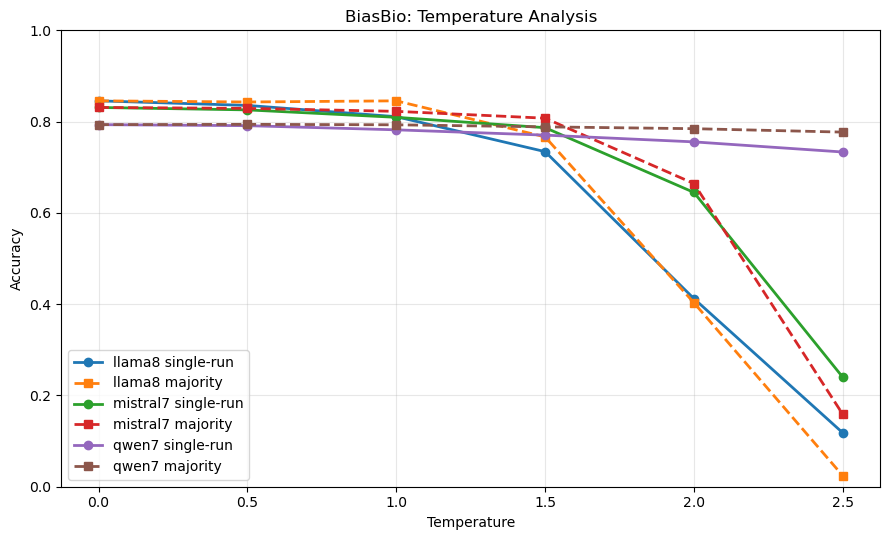

In [56]:
plt.figure(figsize=(9, 5.5))

for judge in plot_df["judge_model"].unique():
    df = plot_df[plot_df["judge_model"] == judge]

    plt.plot(
        df["temperature"],
        df["single_run_accuracy"],
        marker="o",
        linewidth=2,
        label=f"{judge} single-run"
    )

    plt.plot(
        df["temperature"],
        df["majority_accuracy"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"{judge} majority"
    )

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("BiasBio: Temperature Analysis")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("biasbio_temperature_accuracy_plot.png", dpi=300)
plt.show()

## Mean pass/fail/invalid votes per id

In [57]:
# ============================================================
# Vote composition per aggregated example
# PASS / FAIL / INVALID votes
# ============================================================

vote_summary = (
    results_df
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id"
        ]
    )["prediction"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure columns exist even if a class is missing
for col in ["pass", "fail", "invalid"]:
    if col not in vote_summary.columns:
        vote_summary[col] = 0

vote_summary = vote_summary.rename(columns={
    "pass": "pass_votes",
    "fail": "fail_votes",
    "invalid": "invalid_votes"
})

In [58]:
majority_summary_for_mean_votes = (
    vote_summary
    .assign(
        total_votes=lambda x: (
            x["pass_votes"] +
            x["fail_votes"] +
            x["invalid_votes"]
        )
    )
    .assign(
        pass_ratio=lambda x: x["pass_votes"] / x["total_votes"],
        fail_ratio=lambda x: x["fail_votes"] / x["total_votes"],
        invalid_ratio=lambda x: x["invalid_votes"] / x["total_votes"],
    )
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature"
        ],
        as_index=False
    )
    .agg(
        mean_pass_ratio=("pass_ratio", "mean"),
        mean_fail_ratio=("fail_ratio", "mean"),
        mean_invalid_ratio=("invalid_ratio", "mean"),
        n_examples=("id", "count")
    )
)

majority_summary_for_mean_votes.head(20)

,judge_model,generator_model,temperature,mean_pass_ratio,mean_fail_ratio,mean_invalid_ratio,n_examples
0,llama8,mistral7,0.0,0.665000,0.335000,0.000000,2000
1,llama8,mistral7,0.5,0.671800,0.328200,0.000000,2000
2,llama8,mistral7,1.0,0.679800,0.319000,0.001200,2000
3,llama8,mistral7,1.5,0.671100,0.271900,0.057000,2000
4,llama8,mistral7,2.0,0.409800,0.134700,0.455500,2000
5,llama8,mistral7,2.5,0.124600,0.047000,0.828400,2000
6,mistral7,mistral7,0.0,0.732000,0.254000,0.014000,2000
7,mistral7,mistral7,0.5,0.731400,0.250200,0.018400,2000
8,mistral7,mistral7,1.0,0.740500,0.231500,0.028000,2000
9,mistral7,mistral7,1.5,0.751400,0.204200,0.044400,2000


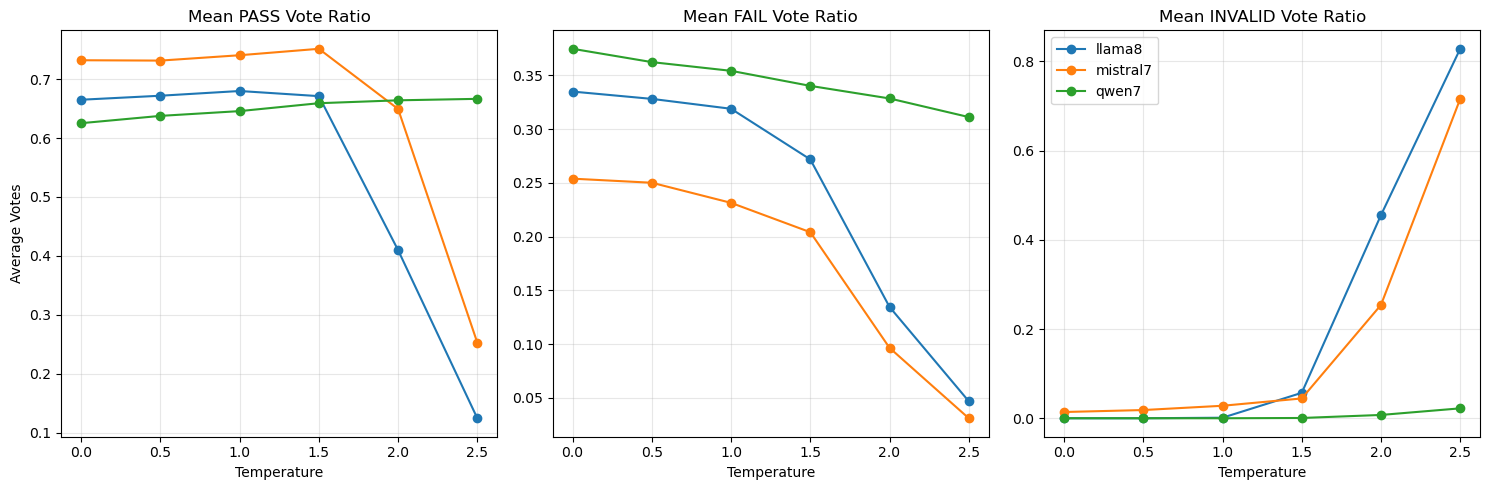

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True
)

metrics = [
    "mean_pass_ratio",
    "mean_fail_ratio",
    "mean_invalid_ratio"
]

titles = [
    "Mean PASS Vote Ratio",
    "Mean FAIL Vote Ratio",
    "Mean INVALID Vote Ratio"
]

for ax, metric, title in zip(axes, metrics, titles):

    for judge in majority_summary_for_mean_votes["judge_model"].unique():

        df_plot = (
            majority_summary_for_mean_votes[
                majority_summary_for_mean_votes["judge_model"] == judge
            ]
            .groupby("temperature")[metric]
            .mean()
            .reset_index()
        )

        ax.plot(
            df_plot["temperature"],
            df_plot[metric],
            marker="o",
            label=judge
        )

    ax.set_title(title)
    ax.set_xlabel("Temperature")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Average Votes")
axes[-1].legend()

plt.tight_layout()

plt.savefig("biasbio_temperature_average_votes_plot.png", dpi=300)
plt.show()

#  ensemble_majority_summary_complete accuracu f1 recal simply majority on judges

In [61]:
#c# ============================================================
# Two-stage / Hierarchical Majority Voting
# 1) Majority across runs for each judge
# 2) Majority across judges for each id
# ============================================================

# ------------------------------------------------------------
# 1. Keep final majority decision of each judge per id
# ------------------------------------------------------------

import numpy as np
# ============================================================
# Ensemble Majority Voting (Majority across Judges)
# ============================================================

# Pivot so that each row contains the majority decision of all judges
judge_votes = (
    majority_df
    .pivot_table(
        index=[
            "id",
            "generator_model",
            "temperature",
            "ground_truth",
            "generator_answer"
        ],
        columns="judge_model",
        values="majority_prediction",
        aggfunc="first"
    )
    .reset_index()
)

judge_votes.columns.name = None

# Expected judge label
judge_votes["expected_label"] = np.where(
    judge_votes["generator_answer"] == judge_votes["ground_truth"],
    "pass",
    "fail"
)

# Keep only examples where all three judges are available
judge_votes_complete = judge_votes.dropna(
    subset=["llama8", "mistral7", "qwen7"]
).copy()


def majority_across_judges(row):
    votes = [
        row["llama8"],
        row["mistral7"],
        row["qwen7"]
    ]

    votes = [v for v in votes if v in ["pass", "fail"]]

    pass_votes = votes.count("pass")
    fail_votes = votes.count("fail")

    if pass_votes > fail_votes:
        return "pass"
    elif fail_votes > pass_votes:
        return "fail"
    else:
        return "tie"


# Majority vote across judges
judge_votes_complete["ensemble_majority_prediction"] = (
    judge_votes_complete.apply(
        majority_across_judges,
        axis=1
    )
)

# Compare against the expected PASS/FAIL label
judge_votes_complete["ensemble_majority_correct"] = (
    judge_votes_complete["ensemble_majority_prediction"]
    == judge_votes_complete["expected_label"]
)

# Accuracy by temperature
ensemble_majority_summary_complete = (
    judge_votes_complete
    .groupby("temperature", as_index=False)
    .agg(
        ensemble_majority_accuracy=("ensemble_majority_correct", "mean"),
        tie_rate=("ensemble_majority_prediction", lambda x: (x == "tie").mean()),
        n=("id", "count")
    )
)

ensemble_majority_summary_complete


,temperature,ensemble_majority_accuracy,tie_rate,n
0,0.0,0.845884,0.002627,1142
1,0.5,0.837000,0.003500,2000
2,1.0,0.839000,0.001500,2000
3,1.5,0.818500,0.006000,2000
4,2.0,0.753589,0.081340,1254
5,2.5,0.758808,0.039295,738


In [90]:
from sklearn.metrics import f1_score, recall_score

positive_label = "pass"

ensemble_ext_rows = []

for temp, group in judge_votes_complete.groupby("temperature"):

    correct = (group["ensemble_majority_prediction"] == group["expected_label"])

    valid_mask = group["ensemble_majority_prediction"].isin(["pass", "fail"])
    y_true = group["expected_label"][valid_mask]
    y_pred = group["ensemble_majority_prediction"][valid_mask]

    ensemble_ext_rows.append({
        "temperature": temp,
        "accuracy":    correct.mean(),
        "f1":     f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "n":      len(group)
    })

ensemble_external_df = (
    pd.DataFrame(ensemble_ext_rows)
    .sort_values("temperature")
    .reset_index(drop=True)
)

ensemble_external_df

,temperature,accuracy,f1,recall,n
0,0.0,0.845884,0.888315,0.905263,1142
1,0.5,0.837000,0.881015,0.907066,2000
2,1.0,0.839000,0.881369,0.910138,2000
3,1.5,0.818500,0.871003,0.909440,2000
4,2.0,0.753589,0.871028,0.895006,1254
5,2.5,0.758808,0.837514,0.831169,738


## normalization of accuracy 

In [62]:
generator_weights = {
    "llama8": 0.7470,
    "mistral7": 0.6515,
    "qwen7": 0.6920
}

total_weight = sum(generator_weights.values())

normalized_generator_weights = {
    model: weight / total_weight
    for model, weight in generator_weights.items()
}

normalized_generator_weights

{'llama8': 0.3573307821095432,
 'mistral7': 0.3116479311169577,
 'qwen7': 0.3310212867734992}

In [63]:
weighted_df = majority_df.copy()

weighted_df["weight"] = weighted_df["judge_model"].map(normalized_generator_weights)

weighted_scores = (
    weighted_df
    .groupby(
        [
            "generator_model",
            "temperature",
            "id",
            "ground_truth",
            "generator_answer",
            "majority_prediction"
        ],
        as_index=False
    )
    .agg(
        score=("weight", "sum")
    )
)

weighted_majority_df = (
    weighted_scores
    .sort_values("score", ascending=False)
    .groupby(
        [
            "generator_model",
            "temperature",
            "id",
            "ground_truth",
            "generator_answer"
        ],
        as_index=False
    )
    .first()
    .rename(columns={"majority_prediction": "weighted_majority_prediction"})
)

weighted_majority_df.head(10)

,generator_model,temperature,id,ground_truth,generator_answer,weighted_majority_prediction,score
0,mistral7,0.0,1,photographer,photographer,pass,1.0
1,mistral7,0.0,10,attorney,attorney,pass,1.0
2,mistral7,0.0,100,dietitian,dietitian,pass,1.0
3,mistral7,0.0,1000,attorney,attorney,pass,1.0
4,mistral7,0.0,1001,filmmaker,filmmaker,pass,1.0
5,mistral7,0.0,1002,chiropractor,chiropractor,pass,1.0
6,mistral7,0.0,1003,surgeon,surgeon,pass,1.0
7,mistral7,0.0,1004,professor,professor,pass,1.0
8,mistral7,0.0,1005,teacher,invalid,fail,1.0
9,mistral7,0.0,1006,teacher,invalid,fail,1.0


# weighted_majority_summary accurasy f1

In [64]:
weighted_majority_df["expected_label"] = np.where(
    weighted_majority_df["generator_answer"] == weighted_majority_df["ground_truth"],
    "pass",
    "fail"
)

weighted_majority_df["weighted_majority_correct"] = (
    weighted_majority_df["weighted_majority_prediction"]
    == weighted_majority_df["expected_label"]
)

weighted_majority_summary = (
    weighted_majority_df
    .groupby(["generator_model", "temperature"])
    .agg(
        weighted_majority_accuracy=("weighted_majority_correct", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

weighted_majority_summary

,generator_model,temperature,weighted_majority_accuracy,n
0,mistral7,0.0,0.8455,2000
1,mistral7,0.5,0.8400,2000
2,mistral7,1.0,0.8400,2000
3,mistral7,1.5,0.8185,2000
4,mistral7,2.0,0.5395,2000
5,mistral7,2.5,0.0765,2000


In [91]:
from sklearn.metrics import f1_score, recall_score

positive_label = "pass"

weighted_ext_rows = []

for keys, group in weighted_majority_df.groupby(["generator_model", "temperature"]):
    generator_model, temp = keys

    correct = (group["weighted_majority_prediction"] == group["expected_label"])

    valid_mask = group["weighted_majority_prediction"].isin(["pass", "fail"])
    y_true = group["expected_label"][valid_mask]
    y_pred = group["weighted_majority_prediction"][valid_mask]

    weighted_ext_rows.append({
        "generator_model": generator_model,
        "temperature":     temp,
        "accuracy":        correct.mean(),
        "f1":     f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "n":      len(group)
    })

weighted_external_df = (
    pd.DataFrame(weighted_ext_rows)
    .sort_values(["generator_model", "temperature"])
    .reset_index(drop=True)
)

weighted_external_df

,generator_model,temperature,accuracy,f1,recall,n
0,mistral7,0.0,0.8455,0.883440,0.898695,2000
1,mistral7,0.5,0.8400,0.880775,0.907137,2000
2,mistral7,1.0,0.8400,0.881129,0.910207,2000
3,mistral7,1.5,0.8185,0.869725,0.909440,2000
4,mistral7,2.0,0.5395,0.854044,0.875000,2000
5,mistral7,2.5,0.0765,0.829670,0.811828,2000


In [65]:
import numpy as np

accuracy_df = results_df.copy()

accuracy_df["expected_label"] = np.where(
    accuracy_df["generator_answer"] == accuracy_df["ground_truth"],
    "pass",
    "fail"
)

accuracy_df["judge_correct"] = (
    accuracy_df["prediction"] == accuracy_df["expected_label"]
)
simple_accuracy_summary = (
    accuracy_df
    .groupby("temperature")
    .agg(
        simple_accuracy=("judge_correct", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

simple_accuracy_summary


,temperature,simple_accuracy,n
0,0.0,0.828277,5142
1,0.5,0.817433,30000
2,1.0,0.800733,30000
3,1.5,0.763767,30000
4,2.0,0.598393,26267
5,2.5,0.396774,23686


In [71]:
plot_df = (
    simple_accuracy_summary[
        ["temperature", "simple_accuracy"]
    ]
    .merge(
        ensemble_majority_summary_complete[
            ["temperature", "ensemble_majority_accuracy"]
        ],
        on="temperature",
        how="inner"
    )
    .merge(
        weighted_majority_summary[
            ["temperature", "weighted_majority_accuracy"]
        ],
        on="temperature",
        how="inner"
    )
)

plot_df

,temperature,simple_accuracy,ensemble_majority_accuracy,weighted_majority_accuracy
0,0.0,0.828277,0.845884,0.8455
1,0.5,0.817433,0.837000,0.8400
2,1.0,0.800733,0.839000,0.8400
3,1.5,0.763767,0.818500,0.8185
4,2.0,0.598393,0.753589,0.5395
5,2.5,0.396774,0.758808,0.0765


In [72]:
plot_df.columns.tolist()

['temperature',
 'simple_accuracy',
 'ensemble_majority_accuracy',
 'weighted_majority_accuracy']

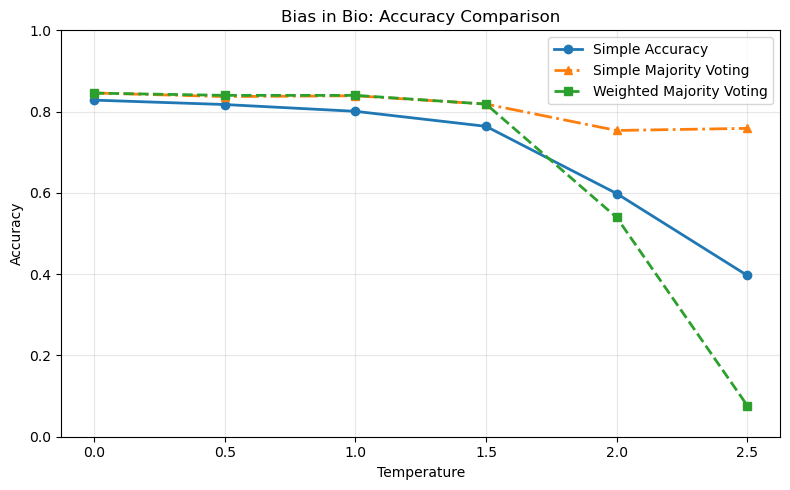

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Simple Accuracy
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["simple_accuracy"],
    marker="o",
    linewidth=2,
    label="Simple Accuracy"
)

# ------------------------------------------------------------
# Simple Majority Voting
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["ensemble_majority_accuracy"],
    marker="^",
    linestyle="-.",
    linewidth=2,
    label="Simple Majority Voting"
)

# ------------------------------------------------------------
# Weighted Majority Voting
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["weighted_majority_accuracy"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Weighted Majority Voting"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("Bias in Bio: Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Simple Accuracy
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["simple_accuracy"],
    marker="o",
    linewidth=2,
    label="Simple Accuracy"
)

# ------------------------------------------------------------
# Simple Majority Voting
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["ensemble_majority_accuracy"],
    marker="^",
    linestyle="-.",
    linewidth=2,
    label="Simple Majority Voting"
)

# ------------------------------------------------------------
# Weighted Majority Voting
# ------------------------------------------------------------
plt.plot(
    plot_df["temperature"],
    plot_df["weighted_majority_accuracy"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Weighted Majority Voting"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("Bias in Bio: Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "biasbio_accuracy_comparison_by_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show().png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
gain_df = (
    majority_acc
    .merge(
        weighted_majority_summary[
            [
                "temperature",
                "weighted_majority_accuracy"
            ]
        ],
        on="temperature",
        how="inner"
    )
)

gain_df["majority_gain"] = (
    gain_df["weighted_majority_accuracy"] -
    gain_df["majority_accuracy"]
)
gain_plot_df = (
    gain_df
    .groupby("temperature", as_index=False)
    .agg(
        majority_gain=("majority_gain", "mean")
    )
)

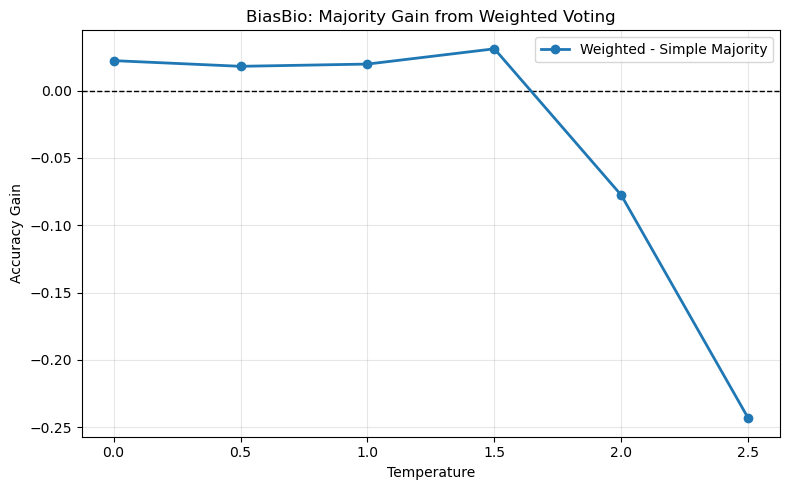

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

plt.plot(
    gain_plot_df["temperature"],
    gain_plot_df["majority_gain"],
    marker="o",
    linewidth=2,
    label="Weighted - Simple Majority"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy Gain")
plt.title("BiasBio: Majority Gain from Weighted Voting")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("biasbio_weighted_majority_gain.png", dpi=300)
plt.show()

## Internal metrics
Agreement Rate (accuracy)
Disagreement Rate
Consistency Rate
Majority Gain
Vote Entropy

In [52]:
# # ============================================================
# # Internal metric 1: Disagreement / Consistency across runs
# # ============================================================
# strict total aggrement rate

# stability_df = (
#     results_df
#     .groupby(
#         [
#             "judge_model",
#             "generator_model",
#             "temperature",
#             "id"
#         ]
#     )
#     .agg(
#         unique_predictions=("prediction", lambda x: x[x.isin(["pass", "fail"])].nunique()),
#         total_runs=("prediction", "count")
#     )
#     .reset_index()
# )

# stability_df["has_disagreement"] = (
#     stability_df["unique_predictions"] != 1
# )

# stability_summary = (
#     stability_df
#     .groupby(
#         [
#             "judge_model",
#             "generator_model",
#             "temperature"
#         ]
#     )
#     .agg(
#         disagreement_rate=("has_disagreement", "mean"),
#         consistency_rate=("has_disagreement", lambda x: 1 - x.mean()),
#         avg_unique_predictions=("unique_predictions", "mean"),
#         n=("id", "count")
#     )
#     .reset_index()
# )

# stability_summary



from itertools import combinations

# ============================================================
# Pairwise Exact Match
# ============================================================

def pairwise_exact_match(predictions):
    preds = list(predictions)

    if len(preds) < 2:
        return 1.0

    matches = 0
    total = 0

    for a, b in combinations(preds, 2):
        total += 1
        if a == b:
            matches += 1

    return matches / total


stability_df = (
    results_df
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id"
        ]
    )
    .agg(
        unique_predictions=("prediction", "nunique"),
        total_runs=("prediction", "count"),
        pairwise_exact_match=("prediction", pairwise_exact_match)
    )
    .reset_index()
)

stability_df["has_disagreement"] = (
    stability_df["unique_predictions"] != 1
)

stability_summary = (
    stability_df
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature"
        ]
    )
    .agg(
        disagreement_rate=("has_disagreement", "mean"),
        pairwise_exact_match=("pairwise_exact_match", "mean"),
        avg_unique_predictions=("unique_predictions", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

stability_summary



,judge_model,generator_model,temperature,disagreement_rate,pairwise_exact_match,avg_unique_predictions,n
0,llama8,mistral7,0.0,0.000000,1.000000,1.000000,2000
1,llama8,mistral7,0.5,0.115500,0.945800,1.115500,2000
2,llama8,mistral7,1.0,0.264000,0.877450,1.267500,2000
3,llama8,mistral7,1.5,0.474000,0.745750,1.588500,2000
4,llama8,mistral7,2.0,0.885500,0.495000,2.132000,2000
5,llama8,mistral7,2.5,0.586500,0.712950,1.664000,2000
6,mistral7,mistral7,0.0,0.000000,1.000000,1.000000,2000
7,mistral7,mistral7,0.5,0.066000,0.967550,1.073000,2000
8,mistral7,mistral7,1.0,0.139500,0.925250,1.168000,2000
9,mistral7,mistral7,1.5,0.220500,0.881850,1.276000,2000


Increasing temperature consistently reduced prediction stability for all judge models. Both disagreement rate and the average number of unique predictions increased as temperature rose, while consistency decreased. Among the evaluated judges, Qwen7 exhibited the highest robustness to temperature changes, maintaining a consistency rate of 58.9% even at T=2.5, whereas Llama8 showed the strongest sensitivity, reaching a disagreement rate of 88.6% at T=2.0. These findings indicate that temperature is a major source of variability in judge decisions and motivate the use of aggregation methods to improve evaluation stability.

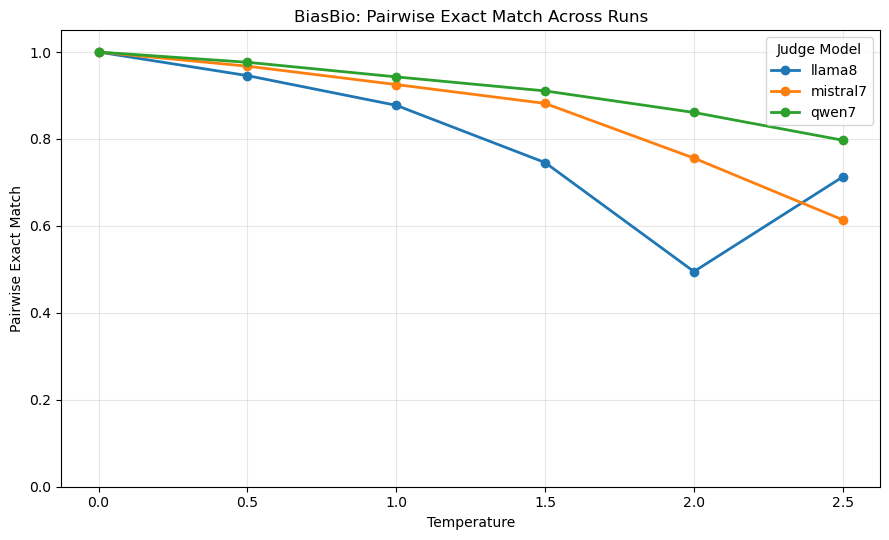

In [56]:
plt.figure(figsize=(9, 5.5))

for judge in stability_summary["judge_model"].unique():

    temp_df = (
        stability_summary[
            stability_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        #temp_df["consistency_rate"],
        temp_df["pairwise_exact_match"],
        marker="o",
        linewidth=2,
        label=judge
    )

plt.xlabel("Temperature")
plt.ylabel("Pairwise Exact Match")
plt.title("BiasBio: Pairwise Exact Match Across Runs")

plt.xticks(
    sorted(stability_summary["temperature"].unique())
)

plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend(title="Judge Model")

plt.tight_layout()

plt.savefig(
    "biasbio_pairwise_exact_match.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Although the disagreement rate of Llama8 decreases from 88.6% at T=2.0 to 58.7% at T=2.5, this does not indicate improved stability. Inspection of the predictions reveals that more than 82% of outputs at T=2.5 are invalid, suggesting that the model collapses towards a dominant invalid response. Consequently, the observed increase in consistency reflects output degeneration rather than genuine robustness.

In [68]:
# Consistency Rate is the complement of the disagreement rate, 
# calculated as 1 minus the disagreement rate. It represents the percentage 
# of samples where there was agreement among the judge's predictions across multiple runs. 
# A higher consistency rate indicates that the judge's predictions are more stable and reliable, 
# while a lower consistency rate suggests more variability and less confidence in the judgments.


In [69]:
# ============================================================
# False Support & False Rejection for BiasBio
# ============================================================

biasbio_interaction = results_df.copy()

# False Support:
# True label is FAIL, but judge predicts PASS
biasbio_interaction["false_support"] = (
    (biasbio_interaction["true_label"] == "fail") &
    (biasbio_interaction["prediction"] == "pass")
)

# False Rejection:
# True label is PASS, but judge predicts FAIL
biasbio_interaction["false_rejection"] = (
    (biasbio_interaction["true_label"] == "pass") &
    (biasbio_interaction["prediction"] == "fail")
)

interaction_summary = (
    biasbio_interaction
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature"
        ],
        as_index=False
    )
    .agg(
        false_support_rate=("false_support", "mean"),
        false_rejection_rate=("false_rejection", "mean"),
        n=("id", "count")
    )
)

interaction_summary

,judge_model,generator_model,temperature,false_support_rate,false_rejection_rate,n
0,llama8,mistral7,0.0,0.084000,0.070500,2000
1,llama8,mistral7,0.5,0.092400,0.072100,10000
2,llama8,mistral7,1.0,0.108200,0.079800,10000
3,llama8,mistral7,1.5,0.120800,0.088000,10000
4,llama8,mistral7,2.0,0.070000,0.062400,10000
5,llama8,mistral7,2.5,0.026100,0.027500,10000
6,mistral7,mistral7,0.0,0.118500,0.036500,2000
7,mistral7,mistral7,0.5,0.118800,0.037100,10000
8,mistral7,mistral7,1.0,0.127400,0.035200,10000
9,mistral7,mistral7,1.5,0.136700,0.032200,10000


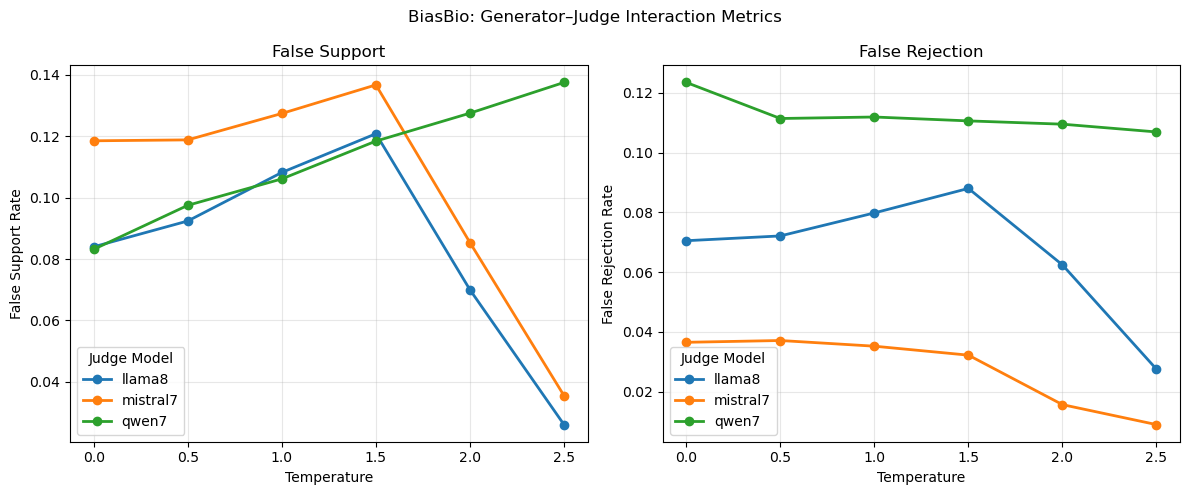

In [59]:
# ============================================================
# False Support & False Rejection
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# False Support
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[0].plot(
        df["temperature"],
        df["false_support_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("False Support Rate")
axes[0].set_title("False Support")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="Judge Model")

# ------------------------------------------------------------
# False Rejection
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[1].plot(
        df["temperature"],
        df["false_rejection_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("False Rejection Rate")
axes[1].set_title("False Rejection")
axes[1].grid(True, alpha=0.3)
axes[1].legend(title="Judge Model")

plt.suptitle(
    "BiasBio: Generator–Judge Interaction Metrics"
)

plt.tight_layout()

plt.savefig(
    "biasbio_false_support_false_rejection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# ============================================================
# Internal metric 2: Aggregation Gain
# Simple Accuracy vs Weighted Majority Voting
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Compute simple accuracy from raw predictions
# ------------------------------------------------------------

accuracy_df = results_df.copy()

accuracy_df["expected_label"] = np.where(
    accuracy_df["generator_answer"] == accuracy_df["ground_truth"],
    "pass",
    "fail"
)

accuracy_df["judge_correct"] = (
    accuracy_df["prediction"] == accuracy_df["expected_label"]
)

simple_accuracy_summary = (
    accuracy_df
    .groupby("temperature")
    .agg(
        simple_accuracy=("judge_correct", "mean"),
        n_simple=("id", "count")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Use weighted majority summary
#    Assumes weighted_majority_summary already exists
# ------------------------------------------------------------

weighted_summary = weighted_majority_summary[
    [
        "temperature",
        "weighted_majority_accuracy",
        "n"
    ]
].copy()

weighted_summary = weighted_summary.rename(
    columns={"n": "n_weighted"}
)

# ------------------------------------------------------------
# 3. Merge simple accuracy with weighted majority accuracy
# ------------------------------------------------------------

aggregation_gain_table = (
    simple_accuracy_summary
    .merge(
        weighted_summary,
        on="temperature",
        how="inner"
    )
    .sort_values("temperature")
)

# ------------------------------------------------------------
# 4. Compute gain
# ------------------------------------------------------------

aggregation_gain_table["aggregation_gain"] = (
    aggregation_gain_table["weighted_majority_accuracy"]
    -
    aggregation_gain_table["simple_accuracy"]
)

# ------------------------------------------------------------
# 5. Clean display table
# ------------------------------------------------------------

aggregation_gain_display = aggregation_gain_table.copy()

for col in [
    "simple_accuracy",
    "weighted_majority_accuracy",
    "aggregation_gain"
]:
    aggregation_gain_display[col] = aggregation_gain_display[col].round(4)

aggregation_gain_display

,temperature,simple_accuracy,n_simple,weighted_majority_accuracy,n_weighted,aggregation_gain
0,0.0,0.8283,5142,0.8455,2000,0.0172
1,0.5,0.8174,30000,0.8400,2000,0.0226
2,1.0,0.8007,30000,0.8400,2000,0.0393
3,1.5,0.7638,30000,0.8185,2000,0.0547
4,2.0,0.5984,26267,0.5395,2000,-0.0589
5,2.5,0.3968,23686,0.0765,2000,-0.3203


# Simple_accuracy weighted_majority_accuracy accuracy	f1	recall	

In [87]:
from sklearn.metrics import f1_score, recall_score

positive_label = "pass"

external_rows = []

# ------------------------------------------------------------
# Simple Accuracy — raw predictions vs expected_label
# ------------------------------------------------------------
for temp, group in accuracy_df.groupby("temperature"):

    valid_mask = group["prediction"].isin(["pass", "fail"])
    y_true = group["expected_label"][valid_mask]
    y_pred = group["prediction"][valid_mask]

    external_rows.append({
        "method":      "simple_accuracy",
        "temperature": temp,
        "accuracy":    group["judge_correct"].mean(),
        "f1":      f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall":  recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "n":       len(group)
    })

# ------------------------------------------------------------
# Weighted Majority — weighted_majority_df vs expected_label
# ------------------------------------------------------------
for temp, group in weighted_majority_df.groupby("temperature"):

    correct = (group["weighted_majority_prediction"] == group["expected_label"])

    valid_mask = group["weighted_majority_prediction"].isin(["pass", "fail"])
    y_true = group["expected_label"][valid_mask]
    y_pred = group["weighted_majority_prediction"][valid_mask]

    external_rows.append({
        "method":      "weighted_majority",
        "temperature": temp,
        "accuracy":    correct.mean(),
        "f1":      f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall":  recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "n":       len(group)
    })

external_metrics_df = (
    pd.DataFrame(external_rows)
    .sort_values(["method", "temperature"])
    .reset_index(drop=True)
)

external_metrics_df

,method,temperature,accuracy,f1,recall,n
0,simple_accuracy,0.0,0.828277,0.875564,0.894439,5142
1,simple_accuracy,0.5,0.817433,0.867460,0.887028,30000
2,simple_accuracy,1.0,0.800733,0.858459,0.883713,30000
3,simple_accuracy,1.5,0.763767,0.849008,0.880816,30000
4,simple_accuracy,2.0,0.598393,0.850375,0.871253,26267
5,simple_accuracy,2.5,0.396774,0.818245,0.837119,23686
6,weighted_majority,0.0,0.845500,0.883440,0.898695,2000
7,weighted_majority,0.5,0.840000,0.880775,0.907137,2000
8,weighted_majority,1.0,0.840000,0.881129,0.910207,2000
9,weighted_majority,1.5,0.818500,0.869725,0.909440,2000


In [71]:
# ============================================================
# Internal metric 2: Majority Gain per Judge
# Single-run Accuracy vs Multi-run Majority Accuracy
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Single-run/simple accuracy per judge
# ------------------------------------------------------------

accuracy_df = results_df.copy()

accuracy_df["expected_label"] = np.where(
    accuracy_df["generator_answer"] == accuracy_df["ground_truth"],
    "pass",
    "fail"
)

accuracy_df["judge_correct"] = (
    accuracy_df["prediction"] == accuracy_df["expected_label"]
)

single_run_summary = (
    accuracy_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        single_run_accuracy=("judge_correct", "mean"),
        n_single=("id", "count")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Multi-run majority accuracy per judge
# ------------------------------------------------------------

majority_eval_df = majority_df.copy()

majority_eval_df["expected_label"] = np.where(
    majority_eval_df["generator_answer"] == majority_eval_df["ground_truth"],
    "pass",
    "fail"
)

majority_eval_df["majority_correct"] = (
    majority_eval_df["majority_prediction"] == majority_eval_df["expected_label"]
)

majority_summary = (
    majority_eval_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        majority_accuracy=("majority_correct", "mean"),
        n_majority=("id", "count")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Majority gain per judge
# ------------------------------------------------------------

majority_gain_table = (
    single_run_summary
    .merge(
        majority_summary,
        on=["judge_model", "generator_model", "temperature"],
        how="inner"
    )
    .sort_values(["judge_model", "temperature"])
)

majority_gain_table["majority_gain"] = (
    majority_gain_table["majority_accuracy"]
    -
    majority_gain_table["single_run_accuracy"]
)

# ------------------------------------------------------------
# 4. Clean display
# ------------------------------------------------------------

majority_gain_display = majority_gain_table.copy()

for col in [
    "single_run_accuracy",
    "majority_accuracy",
    "majority_gain"
]:
    majority_gain_display[col] = majority_gain_display[col].round(4)

majority_gain_display

,judge_model,generator_model,temperature,single_run_accuracy,n_single,majority_accuracy,n_majority,majority_gain
0,llama8,mistral7,0.0,0.8455,2000,0.8455,2000,0.0000
1,llama8,mistral7,0.5,0.8355,10000,0.8430,2000,0.0075
2,llama8,mistral7,1.0,0.8108,10000,0.8455,2000,0.0347
3,llama8,mistral7,1.5,0.7342,10000,0.7665,2000,0.0323
4,llama8,mistral7,2.0,0.4121,10000,0.4030,2000,-0.0091
5,llama8,mistral7,2.5,0.1180,10000,0.0240,2000,-0.0940
6,mistral7,mistral7,0.0,0.8310,2000,0.8310,2000,0.0000
7,mistral7,mistral7,0.5,0.8257,10000,0.8290,2000,0.0033
8,mistral7,mistral7,1.0,0.8094,10000,0.8225,2000,0.0131
9,mistral7,mistral7,1.5,0.7867,10000,0.8075,2000,0.0208


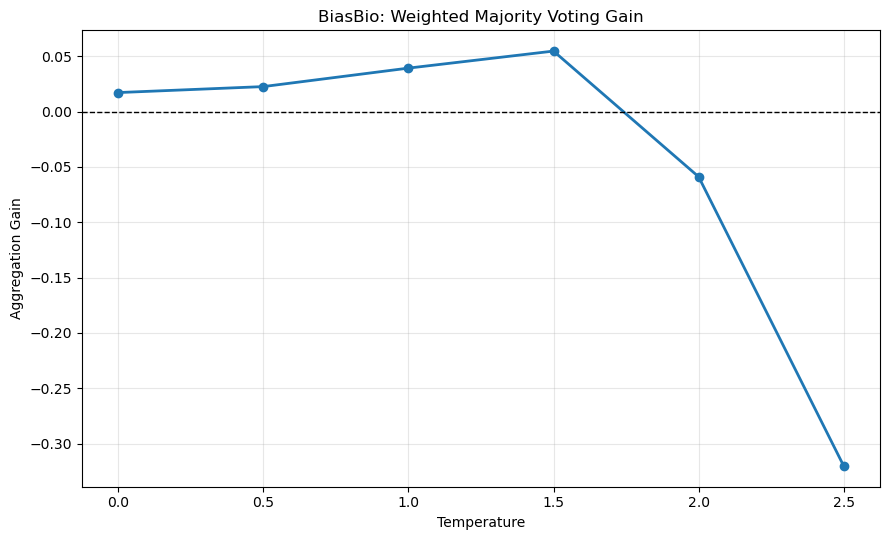

In [72]:
# ============================================================
# Weighted Majority Gain
# ============================================================

plt.figure(figsize=(9, 5.5))

plt.plot(
    aggregation_gain_display["temperature"],
    aggregation_gain_display["aggregation_gain"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temperature")
plt.ylabel("Aggregation Gain")

plt.title(
    "BiasBio: Weighted Majority Voting Gain"
)

plt.xticks(
    sorted(
        aggregation_gain_display["temperature"].unique()
    )
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "biasbio_weighted_majority_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

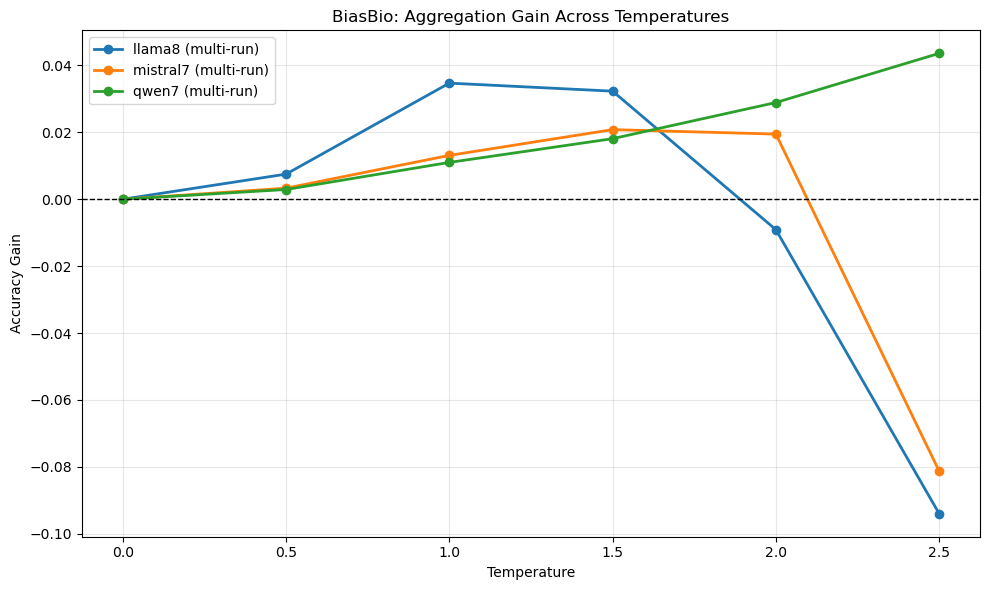

In [79]:
plt.figure(figsize=(10, 6))

# Multi-run gains
for judge in majority_gain_table["judge_model"].unique():

    temp_df = (
        majority_gain_table[
            majority_gain_table["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_gain"],
        marker="o",
        linewidth=2,
        label=f"{judge} (multi-run)"
    )

# Weighted ensemble gain
# plt.plot(
#     aggregation_gain_display["temperature"],
#     aggregation_gain_display["aggregation_gain"],
#     marker="s",
#     linewidth=3,
#     linestyle="--",
#     label="Weighted Ensemble"
# )

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy Gain")

plt.title(
    "BiasBio: Aggregation Gain Across Temperatures"
)

plt.xticks(
    sorted(aggregation_gain_display["temperature"].unique())
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "biasbio_aggregation_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
from sklearn.metrics import recall_score
import numpy as np
import pandas as pd


def make_binary(pred, true):
    pred = str(pred).lower().strip()
    true = str(true).lower().strip()

    if pred in ["pass", "fail"]:
        return pred

    # invalid = wrong
    return "fail" if true == "pass" else "pass"


# ============================================================
# 1. Simple / raw predictions
# ============================================================

simple_df = results_df.copy()

simple_df["expected_label"] = np.where(
    simple_df["generator_answer"] == simple_df["ground_truth"],
    "pass",
    "fail"
)

simple_df["prediction_clean"] = [
    make_binary(pred, true)
    for pred, true in zip(simple_df["prediction"], simple_df["expected_label"])
]

simple_metrics = (
    simple_df
    .groupby("temperature")
    .apply(lambda g: pd.Series({
        "simple_accuracy": (g["prediction_clean"] == g["expected_label"]).mean(),
        "simple_recall": recall_score(
            g["expected_label"],
            g["prediction_clean"],
            pos_label="pass",
            zero_division=0
        ),
        "n_simple": len(g)
    }))
    .reset_index()
)


# ============================================================
# 2. Weighted majority
# ============================================================

weighted_df = weighted_majority_df.copy()

weighted_df["expected_label"] = np.where(
    weighted_df["generator_answer"] == weighted_df["ground_truth"],
    "pass",
    "fail"
)

weighted_df["prediction_clean"] = [
    make_binary(pred, true)
    for pred, true in zip(
        weighted_df["weighted_majority_prediction"],
        weighted_df["expected_label"]
    )
]

weighted_metrics = (
    weighted_df
    .groupby("temperature")
    .apply(lambda g: pd.Series({
        "weighted_majority_accuracy": (
            g["prediction_clean"] == g["expected_label"]
        ).mean(),
        "weighted_majority_recall": recall_score(
            g["expected_label"],
            g["prediction_clean"],
            pos_label="pass",
            zero_division=0
        ),
        "n_weighted": len(g)
    }))
    .reset_index()
)


# ============================================================
# 3. Final table
# ============================================================

accuracy_recall_table = (
    simple_metrics
    .merge(weighted_metrics, on="temperature", how="inner")
    .sort_values("temperature")
)

accuracy_recall_table["accuracy_gain"] = (
    accuracy_recall_table["weighted_majority_accuracy"]
    - accuracy_recall_table["simple_accuracy"]
)

accuracy_recall_table["recall_gain"] = (
    accuracy_recall_table["weighted_majority_recall"]
    - accuracy_recall_table["simple_recall"]
)

accuracy_recall_table.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_6120\636845502.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\georg\AppData\Local\Temp\ipykernel_6120\636845502.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,temperature,simple_accuracy,simple_recall,n_simple,weighted_majority_accuracy,weighted_majority_recall,n_weighted,accuracy_gain,recall_gain
0,0.0,0.8283,0.8936,5142.0,0.8455,0.8987,2000.0,0.0172,0.0051
1,0.5,0.8174,0.8862,30000.0,0.8400,0.9071,2000.0,0.0226,0.0209
2,1.0,0.8007,0.8822,30000.0,0.8400,0.9102,2000.0,0.0393,0.0280
3,1.5,0.7638,0.8727,30000.0,0.8185,0.9094,2000.0,0.0547,0.0367
4,2.0,0.5984,0.7152,26267.0,0.5395,0.7252,2000.0,-0.0589,0.0100
5,2.5,0.3968,0.4580,23686.0,0.0765,0.1159,2000.0,-0.3203,-0.3421


In [72]:
# ============================================================
# False Support / False Rejection
# Uses majority-voted predictions across runs
# ============================================================

interaction_df = majority_df.copy()

interaction_df["expected_label"] = np.where(
    interaction_df["generator_answer"] == interaction_df["ground_truth"],
    "pass",
    "fail"
)

interaction_df["judge_pass"] = (
    interaction_df["majority_prediction"] == "pass"
)

interaction_summary = (
    interaction_df
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature"
        ]
    )
    .apply(
        lambda g: pd.Series({

            "false_support_rate":
                (
                    (
                        (g["expected_label"] == "fail")
                        &
                        (g["judge_pass"])
                    ).sum()
                )
                /
                max(
                    (g["expected_label"] == "fail").sum(),
                    1
                ),

            "false_rejection_rate":
                (
                    (
                        (g["expected_label"] == "pass")
                        &
                        (~g["judge_pass"])
                    ).sum()
                )
                /
                max(
                    (g["expected_label"] == "pass").sum(),
                    1
                ),

            "n":
                len(g)

        })
    )
    .reset_index()
)

interaction_summary.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_21016\2579983597.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,judge_model,generator_model,temperature,false_support_rate,false_rejection_rate,n
0,llama8,mistral7,0.0,0.2410,0.1082,2000.0
1,llama8,mistral7,0.5,0.2511,0.1067,2000.0
2,llama8,mistral7,1.0,0.2425,0.1067,2000.0
3,llama8,mistral7,1.5,0.3113,0.1197,2000.0
4,llama8,mistral7,2.0,0.1506,0.3945,2000.0
5,llama8,mistral7,2.5,0.0158,0.9555,2000.0
6,mistral7,mistral7,0.0,0.3400,0.0583,2000.0
7,mistral7,mistral7,0.5,0.3329,0.0591,2000.0
8,mistral7,mistral7,1.0,0.3443,0.0553,2000.0
9,mistral7,mistral7,1.5,0.3587,0.0499,2000.0


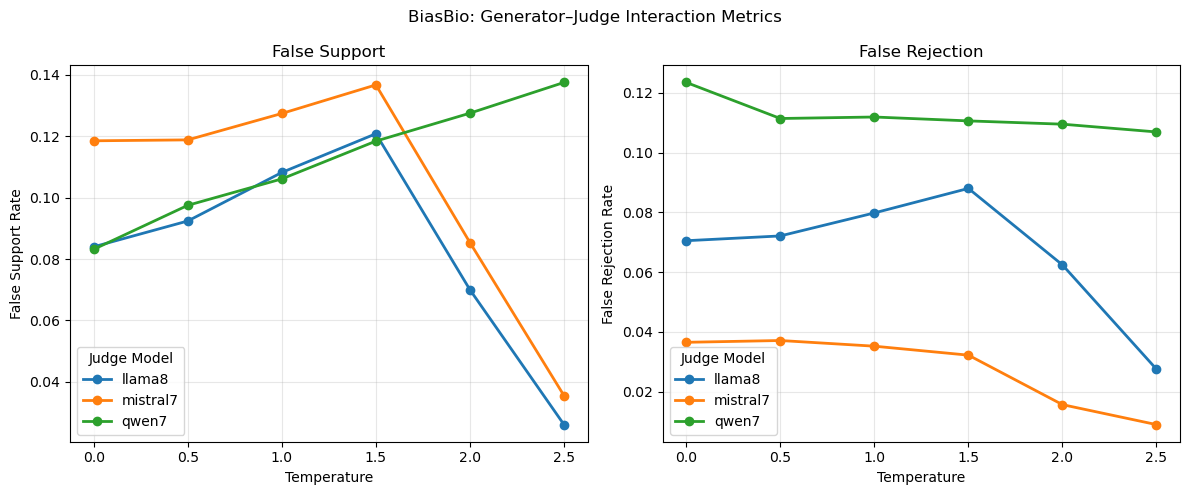

In [80]:
# ============================================================
# False Support & False Rejection
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# False Support
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[0].plot(
        df["temperature"],
        df["false_support_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("False Support Rate")
axes[0].set_title("False Support")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="Judge Model")

# ------------------------------------------------------------
# False Rejection
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[1].plot(
        df["temperature"],
        df["false_rejection_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("False Rejection Rate")
axes[1].set_title("False Rejection")
axes[1].grid(True, alpha=0.3)
axes[1].legend(title="Judge Model")

plt.suptitle(
    "BiasBio: Generator–Judge Interaction Metrics"
)

plt.tight_layout()

plt.savefig(
    "biasbio_false_support_false_rejection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Increasing temperature does not simply reduce evaluation accuracy. Instead, it systematically changes the error profile of the judge models. While Qwen7 maintains a relatively stable balance between false support and false rejection across temperatures, Llama8 and Mistral7 exhibit a pronounced shift from permissive behaviour to excessive rejection at high temperatures. This indicates that temperature affects not only correctness but also the underlying evaluation strategy adopted by the judge.

In [74]:
# ============================================================
# Invalid Rate across majority-voted predictions
# ============================================================

invalid_summary = (
    majority_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        invalid_rate=(
            "majority_prediction",
            lambda x: (~x.isin(["pass", "fail"])).mean()
        ),
        n=("id", "count")
    )
    .reset_index()
)

invalid_summary

,judge_model,generator_model,temperature,invalid_rate,n
0,llama8,mistral7,0.0,0.000000,2000
1,llama8,mistral7,0.5,0.000000,2000
2,llama8,mistral7,1.0,0.000000,2000
3,llama8,mistral7,1.5,0.022500,2000
4,llama8,mistral7,2.0,0.467500,2000
5,llama8,mistral7,2.5,0.961500,2000
6,mistral7,mistral7,0.0,0.014000,2000
7,mistral7,mistral7,0.5,0.016500,2000
8,mistral7,mistral7,1.0,0.020000,2000
9,mistral7,mistral7,1.5,0.025500,2000


In [75]:
interaction_summary_with_invalid = (
    interaction_summary
    .merge(
        invalid_summary[
            [
                "judge_model",
                "generator_model",
                "temperature",
                "invalid_rate"
            ]
        ],
        on=[
            "judge_model",
            "generator_model",
            "temperature"
        ],
        how="left"
    )
)

interaction_summary_with_invalid.round(4)

,judge_model,generator_model,temperature,false_support_rate,false_rejection_rate,n,invalid_rate
0,llama8,mistral7,0.0,0.2410,0.1082,2000.0,0.0000
1,llama8,mistral7,0.5,0.2511,0.1067,2000.0,0.0000
2,llama8,mistral7,1.0,0.2425,0.1067,2000.0,0.0000
3,llama8,mistral7,1.5,0.3113,0.1197,2000.0,0.0225
4,llama8,mistral7,2.0,0.1506,0.3945,2000.0,0.4675
5,llama8,mistral7,2.5,0.0158,0.9555,2000.0,0.9615
6,mistral7,mistral7,0.0,0.3400,0.0583,2000.0,0.0140
7,mistral7,mistral7,0.5,0.3329,0.0591,2000.0,0.0165
8,mistral7,mistral7,1.0,0.3443,0.0553,2000.0,0.0200
9,mistral7,mistral7,1.5,0.3587,0.0499,2000.0,0.0255


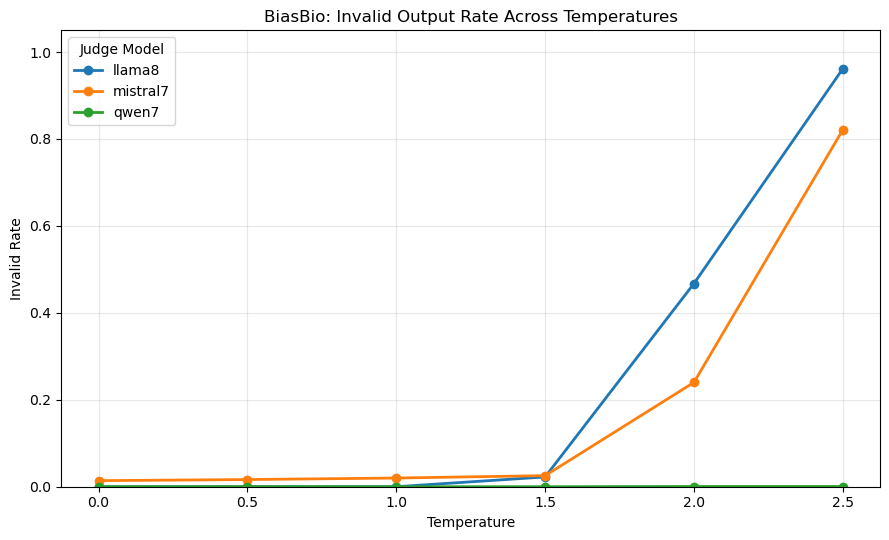

In [76]:
# ============================================================
# Invalid Rate Across Temperatures
# ============================================================

plt.figure(figsize=(9, 5.5))

for judge in invalid_summary["judge_model"].unique():

    temp_df = (
        invalid_summary[
            invalid_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["invalid_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

plt.xlabel("Temperature")
plt.ylabel("Invalid Rate")

plt.title(
    "BiasBio: Invalid Output Rate Across Temperatures"
)

plt.xticks(
    sorted(
        invalid_summary["temperature"].unique()
    )
)

plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend(title="Judge Model")

plt.tight_layout()

plt.savefig(
    "biasbio_invalid_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
interaction_diagnostics = (
    interaction_summary
    .merge(
        invalid_summary[
            [
                "judge_model",
                "temperature",
                "invalid_rate"
            ]
        ],
        on=[
            "judge_model",
            "temperature"
        ],
        how="left"
    )
)

interaction_diagnostics.round(4)

,judge_model,generator_model,temperature,false_support_rate,false_rejection_rate,n,invalid_rate
0,llama8,mistral7,0.0,0.2410,0.1082,2000.0,0.0000
1,llama8,mistral7,0.5,0.2511,0.1067,2000.0,0.0000
2,llama8,mistral7,1.0,0.2425,0.1067,2000.0,0.0000
3,llama8,mistral7,1.5,0.3113,0.1197,2000.0,0.0225
4,llama8,mistral7,2.0,0.1506,0.3945,2000.0,0.4675
5,llama8,mistral7,2.5,0.0158,0.9555,2000.0,0.9615
6,mistral7,mistral7,0.0,0.3400,0.0583,2000.0,0.0140
7,mistral7,mistral7,0.5,0.3329,0.0591,2000.0,0.0165
8,mistral7,mistral7,1.0,0.3443,0.0553,2000.0,0.0200
9,mistral7,mistral7,1.5,0.3587,0.0499,2000.0,0.0255


## extrernal 

Αν σε ρωτήσει ο καθηγητής, εγώ θα το υπερασπιζόμουν κάπως έτσι:

---

### Handling of Invalid Judge Outputs

During the evaluation process, some judge models occasionally produced outputs that did not conform to the expected label space (`PASS` or `FAIL`). These outputs were categorized as *invalid predictions*. The treatment of invalid predictions depended on the objective of each metric.

#### Accuracy-Based Metrics

For all accuracy-based metrics, including:

* Single-Run Accuracy
* Multi-Run Majority Accuracy
* Weighted Majority Accuracy
* Aggregation Gain

invalid predictions were treated as **incorrect decisions**.

The rationale is that, in a practical evaluation pipeline, an invalid output cannot be used as a valid judgment. Therefore, regardless of the underlying ground-truth label, an invalid prediction represents a failure of the evaluation system and should reduce overall performance.

Formally:

```text
PASS expected + INVALID prediction → incorrect
FAIL expected + INVALID prediction → incorrect
```

This approach prevents artificially inflating performance by excluding failed outputs from the evaluation.

---

#### Stability and Consistency Metrics

For robustness metrics such as:

* Disagreement Rate
* Consistency Rate
* Average Unique Predictions

invalid outputs were treated as a **separate prediction category**.

For example:

```text
PASS, PASS, INVALID, PASS, PASS
```

contains two unique predictions:

```text
{PASS, INVALID}
```

and therefore contributes to disagreement.

This treatment is intentional, since the objective of these metrics is to quantify behavioral variability rather than correctness. Invalid outputs represent a meaningful form of instability and should therefore contribute to disagreement measurements.

---

#### False Support and False Rejection Metrics

For the Generator–Judge interaction analysis, invalid predictions were treated as **non-PASS decisions**.

Specifically:

```text
PASS    → positive judgment
FAIL    → negative judgment
INVALID → negative judgment
```

Consequently, invalid outputs contribute to False Rejection but not to False Support.

This design reflects the fact that an invalid output cannot be interpreted as an endorsement of the generator's answer. However, because high temperatures can substantially increase the frequency of invalid outputs, False Rejection rates were always interpreted together with the Invalid Rate metric.

---

#### Separate Invalid Rate Reporting

To avoid conflating strictness with output degeneration, invalid predictions were additionally reported through a dedicated Invalid Rate metric.

This allows distinguishing between two different phenomena:

1. **Genuine evaluation strictness**

```text
PASS → FAIL
```

2. **Output collapse**

```text
PASS → INVALID
```

For example, at high temperatures, some judges exhibited a sharp increase in False Rejection. Examination of the Invalid Rate revealed that this behavior was primarily caused by a large number of invalid outputs rather than by a systematic increase in evaluation strictness.

---

Αυτό είναι αρκετά ισχυρό μεθοδολογικά γιατί:

* δεν κρύβεις τα invalid,
* δεν τα αγνοείς,
* δεν τα μετράς παντού σαν fail,
* και εξηγείς γιατί κάθε metric τα χειρίζεται διαφορετικά ανάλογα με το τι μετράει.

Αν το παρουσιάσεις έτσι σε viva ή defense, είναι πολύ δύσκολο να σου πουν ότι είναι λάθος επιλογή. Είναι απολύτως defendable.


Invalid judge outputs were retained throughout the analysis rather than discarded, as they represent a meaningful failure mode of the evaluation system. For accuracy-based metrics, including single-run accuracy, majority accuracy, weighted majority accuracy, and aggregation gain, invalid predictions were treated as incorrect decisions, since they cannot be interpreted as valid judgments in a practical evaluation pipeline. For robustness metrics, such as disagreement rate and consistency rate, invalid outputs were treated as a separate prediction category, allowing them to contribute to observed variability between runs. In the Generator–Judge interaction analysis, invalid outputs were considered non-PASS decisions and therefore contributed to false rejection behaviour. To avoid conflating strict evaluation behaviour with output degeneration, invalid predictions were additionally reported through a dedicated Invalid Rate metric. This approach ensures that invalid outputs are neither ignored nor artificially mapped to valid labels, while still allowing their impact on both performance and robustness to be analysed explicitly.

# External

In [77]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ============================================================
# 0. Setup
# ============================================================

df = results_df.copy()

positive_label = "pass"

judge_weights = {
    "llama8": 0.3573307821095432,
    "mistral7": 0.3116479311169577,
    "qwen7": 0.3310212867734992
}

df["prediction"] = df["prediction"].astype(str).str.lower().str.strip()
df["true_label"] = df["true_label"].astype(str).str.lower().str.strip()
df["judge_model"] = df["judge_model"].astype(str).str.lower().str.strip()
df["generator_model"] = df["generator_model"].astype(str).str.lower().str.strip()
df["mode"] = df["mode"].astype(str).str.lower().str.strip()


# ============================================================
# 1. Metric helper
# ============================================================

def compute_metrics(y_true, y_pred, method, judge_model=None,
                    generator_model=None, temperature=None):
    return {
        "method": method,
        "judge_model": judge_model,
        "generator_model": generator_model,
        "temperature": temperature,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
        "n": len(y_true)
    }


def wrong_label(true_label):
    if true_label == "pass":
        return "fail"
    elif true_label == "fail":
        return "pass"
    else:
        return None


def majority_vote_with_tie_penalty(group):
    counts = group["prediction"].value_counts()

    if counts.empty:
        return None

    if (counts == counts.max()).sum() > 1:
        true_label = group["true_label"].iloc[0]
        return wrong_label(true_label)

    return counts.idxmax()


def weighted_majority_vote_with_tie_penalty(group):
    pass_score = 0.0
    fail_score = 0.0

    for _, row in group.iterrows():
        vote = row["prediction"]
        judge = row["judge_model"]
        weight = judge_weights.get(judge, 0.0)

        if vote == "pass":
            pass_score += weight
        elif vote == "fail":
            fail_score += weight

    if pass_score > fail_score:
        return "pass"
    elif fail_score > pass_score:
        return "fail"
    else:
        true_label = group["true_label"].iloc[0]
        return wrong_label(true_label)


metric_rows = []


# ============================================================
# 2. Oneshot metrics
# ============================================================

oneshot_df = df[df["mode"] == "oneshot"].copy()

for keys, group in oneshot_df.groupby(
    ["judge_model", "generator_model", "temperature"]
):
    judge_model, generator_model, temperature = keys

    group = group[group["prediction"].isin(["pass", "fail"])].copy()

    metric_rows.append(
        compute_metrics(
            group["true_label"],
            group["prediction"],
            method="oneshot",
            judge_model=judge_model,
            generator_model=generator_model,
            temperature=temperature
        )
    )


# ============================================================
# 3. Multirun majority
# ============================================================

multirun_df = df[df["mode"] == "multirun"].copy()

multirun_majority = (
    multirun_df
    .groupby(
        ["judge_model", "generator_model", "temperature", "id"],
        as_index=False
    )
    .apply(
        lambda g: pd.Series({
            "prediction": majority_vote_with_tie_penalty(g),
            "true_label": g["true_label"].iloc[0],
            "n_votes": len(g)
        })
    )
    .reset_index(drop=True)
)

multirun_majority = multirun_majority[
    multirun_majority["prediction"].isin(["pass", "fail"])
].copy()

for keys, group in multirun_majority.groupby(
    ["judge_model", "generator_model", "temperature"]
):
    judge_model, generator_model, temperature = keys

    metric_rows.append(
        compute_metrics(
            group["true_label"],
            group["prediction"],
            method="multirun_majority",
            judge_model=judge_model,
            generator_model=generator_model,
            temperature=temperature
        )
    )


# ============================================================
# 4. Judge-level votes
# Collapse multirun first, keep oneshot as single vote
# ============================================================

judge_level_votes = (
    df
    .groupby(
        ["judge_model", "generator_model", "temperature", "id"],
        as_index=False
    )
    .apply(
        lambda g: pd.Series({
            "prediction": majority_vote_with_tie_penalty(g),
            "true_label": g["true_label"].iloc[0]
        })
    )
    .reset_index(drop=True)
)

judge_level_votes = judge_level_votes[
    judge_level_votes["prediction"].isin(["pass", "fail"])
].copy()


# ============================================================
# 5. Multi-judge majority
# ============================================================

multi_judge_majority = (
    judge_level_votes
    .groupby(
        ["generator_model", "temperature", "id"],
        as_index=False
    )
    .apply(
        lambda g: pd.Series({
            "prediction": majority_vote_with_tie_penalty(g),
            "true_label": g["true_label"].iloc[0],
            "n_judges": g["judge_model"].nunique()
        })
    )
    .reset_index(drop=True)
)

for keys, group in multi_judge_majority.groupby(
    ["generator_model", "temperature"]
):
    generator_model, temperature = keys

    metric_rows.append(
        compute_metrics(
            group["true_label"],
            group["prediction"],
            method="multi_judge_majority",
            judge_model="ensemble",
            generator_model=generator_model,
            temperature=temperature
        )
    )


# ============================================================
# 6. Multi-judge weighted majority
# ============================================================

multi_judge_weighted = (
    judge_level_votes
    .groupby(
        ["generator_model", "temperature", "id"],
        as_index=False
    )
    .apply(
        lambda g: pd.Series({
            "prediction": weighted_majority_vote_with_tie_penalty(g),
            "true_label": g["true_label"].iloc[0],
            "n_judges": g["judge_model"].nunique()
        })
    )
    .reset_index(drop=True)
)

for keys, group in multi_judge_weighted.groupby(
    ["generator_model", "temperature"]
):
    generator_model, temperature = keys

    metric_rows.append(
        compute_metrics(
            group["true_label"],
            group["prediction"],
            method="multi_judge_weighted_majority",
            judge_model="weighted_ensemble",
            generator_model=generator_model,
            temperature=temperature
        )
    )


# ============================================================
# 7. Final external metrics table
# ============================================================

external_metrics_df = pd.DataFrame(metric_rows)

external_metrics_df = external_metrics_df.sort_values(
    ["method", "generator_model", "judge_model", "temperature"]
).reset_index(drop=True)

external_metrics_df

C:\Users\georg\AppData\Local\Temp\ipykernel_6120\3480762107.py:144: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\georg\AppData\Local\Temp\ipykernel_6120\3480762107.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\georg\AppData\Local\Temp\ipykernel_6120\3480762107.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in 

,method,judge_model,generator_model,temperature,accuracy,precision,recall,f1,n
0,multi_judge_majority,ensemble,mistral7,0.0,0.818500,0.840087,0.891021,0.864804,2000
1,multi_judge_majority,ensemble,mistral7,0.5,0.837000,0.852708,0.906370,0.878720,2000
2,multi_judge_majority,ensemble,mistral7,1.0,0.839000,0.853132,0.909440,0.880386,2000
3,multi_judge_majority,ensemble,mistral7,1.5,0.818500,0.828671,0.909440,0.867179,2000
4,multi_judge_majority,ensemble,mistral7,2.0,0.727000,0.782674,0.804298,0.793338,2000
5,multi_judge_majority,ensemble,mistral7,2.5,0.755000,0.814385,0.808135,0.811248,2000
6,multi_judge_weighted_majority,weighted_ensemble,mistral7,0.0,0.845500,0.868694,0.898695,0.883440,2000
7,multi_judge_weighted_majority,weighted_ensemble,mistral7,0.5,0.840000,0.855902,0.907137,0.880775,2000
8,multi_judge_weighted_majority,weighted_ensemble,mistral7,1.0,0.840000,0.853852,0.910207,0.881129,2000
9,multi_judge_weighted_majority,weighted_ensemble,mistral7,1.5,0.820500,0.830996,0.909440,0.868450,2000


Since the judge does not directly predict the occupation label but instead evaluates whether the generator prediction is correct, external performance metrics were computed in a binary evaluation space. First, the expected judge label was derived by comparing the generator output with the ground-truth occupation. If the generator prediction matched the reference occupation, the expected judge decision was PASS; otherwise, FAIL. Judge predictions were then compared against these expected labels to compute Accuracy, Precision, Recall, and F1-score. This formulation evaluates the judge's ability to correctly assess generator outputs rather than its ability to solve the original occupation classification task.

Since the BiasBio judge does not directly predict the occupation label, external evaluation was performed in a derived binary label space. The generator output was first compared against the ground-truth occupation. If the predicted occupation matched the ground truth, the expected judge label was defined as PASS; otherwise, it was defined as FAIL. The judge prediction was then evaluated against this expected binary label. Invalid outputs, namely responses that could not be normalized to either PASS or FAIL, were counted as incorrect for the main accuracy metric. In addition, valid-only precision, recall and F1-score were reported as supplementary metrics. This distinction is important because, at higher temperatures, some judges increasingly fail to follow the required output format. Therefore, valid-only F1 may remain high even when the overall accuracy decreases sharply, since F1 is computed only over valid PASS/FAIL predictions, while accuracy including invalids penalizes format failures.

In [92]:
external_metrics_df = pd.concat([
    majority_external_df.assign(method="multirun_majority"),
    ensemble_external_df.assign(method="ensemble_majority"),
    weighted_external_df.assign(method="weighted_majority"),
], ignore_index=True
).sort_values(["method", "generator_model", "judge_model", "temperature"]
).reset_index(drop=True)

external_metrics_df

,judge_model,generator_model,temperature,accuracy,f1,recall,n,method
0,NaN,NaN,0.0,0.845884,0.888315,0.905263,1142,ensemble_majority
1,NaN,NaN,0.5,0.837000,0.881015,0.907066,2000,ensemble_majority
2,NaN,NaN,1.0,0.839000,0.881369,0.910138,2000,ensemble_majority
3,NaN,NaN,1.5,0.818500,0.871003,0.909440,2000,ensemble_majority
4,NaN,NaN,2.0,0.753589,0.871028,0.895006,1254,ensemble_majority
5,NaN,NaN,2.5,0.758808,0.837514,0.831169,738,ensemble_majority
6,llama8,mistral7,0.0,0.845500,0.882643,0.891788,2000,multirun_majority
7,llama8,mistral7,0.5,0.843000,0.881151,0.893323,2000,multirun_majority
8,llama8,mistral7,1.0,0.845500,0.882732,0.892556,2000,multirun_majority
9,llama8,mistral7,1.5,0.766500,0.836937,0.876439,2000,multirun_majority


# task spesific

In [93]:
# Merge gender back from results_df
majority_df_gender = majority_df.merge(
    results_df[["id", "gender"]].drop_duplicates("id"),
    on="id",
    how="left"
)

majority_df_gender["expected_label"] = np.where(
    majority_df_gender["generator_answer"] == majority_df_gender["ground_truth"],
    "pass",
    "fail"
)

majority_df_gender["majority_correct"] = (
    majority_df_gender["majority_prediction"] == majority_df_gender["expected_label"]
)

# ============================================================
# Gender-specific accuracy and gender gap
# ============================================================

gender_rows = []

for keys, group in majority_df_gender.groupby(
    ["judge_model", "generator_model", "temperature"]
):
    judge_model, generator_model, temp = keys

    male   = group[group["gender"] == "male"]
    female = group[group["gender"] == "female"]

    acc_m = male["majority_correct"].mean()
    acc_f = female["majority_correct"].mean()

    gender_rows.append({
        "judge_model":     judge_model,
        "generator_model": generator_model,
        "temperature":     temp,
        "acc_male":        acc_m,
        "acc_female":      acc_f,
        "gender_gap":      abs(acc_m - acc_f),
        "n_male":          len(male),
        "n_female":        len(female)
    })

gender_acc_df = (
    pd.DataFrame(gender_rows)
    .sort_values(["judge_model", "generator_model", "temperature"])
    .reset_index(drop=True)
)

gender_acc_df

,judge_model,generator_model,temperature,acc_male,acc_female,gender_gap,n_male,n_female
0,llama8,mistral7,0.0,0.838353,0.852590,0.014236,996,1004
1,llama8,mistral7,0.5,0.833333,0.852590,0.019256,996,1004
2,llama8,mistral7,1.0,0.844378,0.846614,0.002236,996,1004
3,llama8,mistral7,1.5,0.762048,0.770916,0.008868,996,1004
4,llama8,mistral7,2.0,0.405622,0.400398,0.005224,996,1004
5,llama8,mistral7,2.5,0.025100,0.022908,0.002192,996,1004
6,mistral7,mistral7,0.0,0.821285,0.840637,0.019352,996,1004
7,mistral7,mistral7,0.5,0.817269,0.840637,0.023368,996,1004
8,mistral7,mistral7,1.0,0.810241,0.834661,0.024420,996,1004
9,mistral7,mistral7,1.5,0.795181,0.819721,0.024540,996,1004


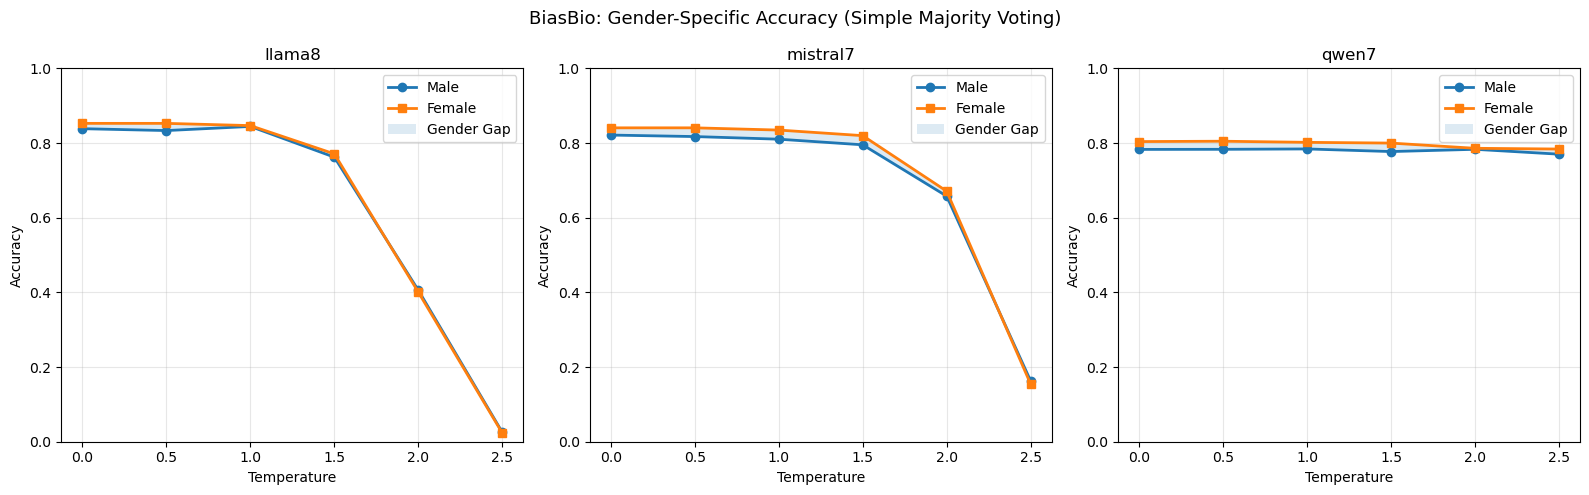

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

judges = sorted(gender_acc_df["judge_model"].unique())

for ax, judge in zip(axes, judges):

    df = (
        gender_acc_df[gender_acc_df["judge_model"] == judge]
        .sort_values("temperature")
    )

    ax.plot(
        df["temperature"], df["acc_male"],
        marker="o", linewidth=2, label="Male"
    )

    ax.plot(
        df["temperature"], df["acc_female"],
        marker="s", linewidth=2, label="Female"
    )

    ax.fill_between(
        df["temperature"],
        df["acc_male"],
        df["acc_female"],
        alpha=0.15,
        label="Gender Gap"
    )

    ax.set_title(judge)
    ax.set_xlabel("Temperature")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("BiasBio: Gender-Specific Accuracy (Simple Majority Voting)", fontsize=13)
plt.tight_layout()

plt.savefig("biasbio_gender_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()